
PHYSICAL INTERFEROGRAM

DET1 visibility : 1.000000
DET2 visibility : 1.000000


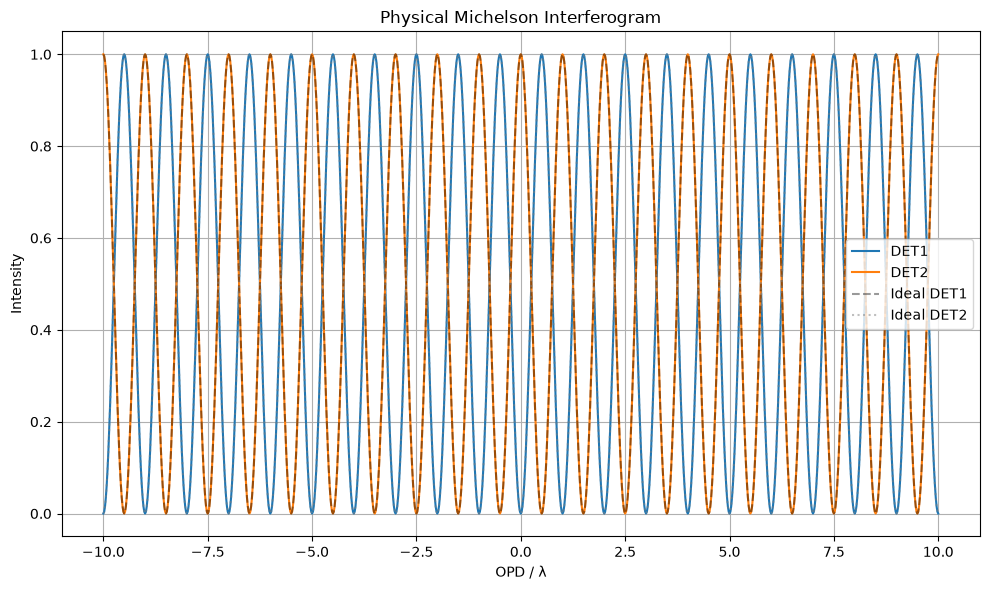

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from optics.bundle_source import CircularBundleSource

from architectures.classic_michelson import (
    ClassicMichelson
)

from materials.constant_index import (
    ConstantIndex
)

# =====================================================
# PARAMETERS
# =====================================================

wavelength = 632.8e-9

bk7 = ConstantIndex(
    1.5168,
    "BK7",
)

# =====================================================
# SOURCE
# =====================================================

source = CircularBundleSource(

    position=[-50,0,0],

    direction=[1,0,0],

    wavelength=wavelength,

    radius=0.1,

    n_rays=1,
)

# =====================================================
# MICHELSON
# =====================================================

michelson = ClassicMichelson(

    arm_length=150,

    compensator_distance=50,

    mirror_size=30,

    plate_size=50,

    plate_thickness=10,

    material=bk7,
)

michelson.set_source(
    source
)

# =====================================================
# MIRROR SCAN
# =====================================================

#
# Physical mirror displacement
#
# OPD = 2 × displacement
#

mirror_positions = np.linspace(
    -5*wavelength,
    +5*wavelength,
    1001,
)

# =====================================================
# INTERFEROGRAM
# =====================================================

result = michelson.scan_mirror(
    mirror_positions
)

det1 = result["det1"]
det2 = result["det2"]

opd = result["opd"]

# =====================================================
# VISIBILITY
# =====================================================

def visibility(signal):

    Imax = np.max(signal)
    Imin = np.min(signal)

    return (
        (Imax - Imin)
        /
        (Imax + Imin)
    )

vis1 = visibility(det1)
vis2 = visibility(det2)

print()
print("====================================")
print("PHYSICAL INTERFEROGRAM")
print("====================================")
print()

print(
    f"DET1 visibility : {vis1:.6f}"
)

print(
    f"DET2 visibility : {vis2:.6f}"
)

# =====================================================
# IDEAL THEORY
# =====================================================

theory1 = 0.5 * (
    1
    + np.cos(
        2*np.pi * opd / wavelength
    )
)

theory2 = 1.0 - theory1

# =====================================================
# PLOT
# =====================================================

plt.figure(
    figsize=(10,6)
)

plt.plot(
    opd / wavelength,
    det1,

    label="DET1",
)

plt.plot(
    opd / wavelength,
    det2,

    label="DET2",
)

plt.plot(
    opd / wavelength,
    theory1,

    "--",
    color="black",
    alpha=0.4,

    label="Ideal DET1",
)

plt.plot(
    opd / wavelength,
    theory2,

    ":",
    color="gray",
    alpha=0.5,

    label="Ideal DET2",
)

plt.xlabel(
    "OPD / λ"
)

plt.ylabel(
    "Intensity"
)

plt.title(
    "Physical Michelson Interferogram"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()